In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("/content/breast-cancer.csv")

In [2]:
print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
print(df.describe())

                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813     

In [6]:
print(df.shape)

(569, 32)


In [7]:
print(df.isnull().sum())

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [8]:
print(df.duplicated().sum())

0


In [9]:
df.drop("id" ,axis=1 , inplace=True)

In [10]:
df["diagnosis"] = df["diagnosis"].map({
    "M":1,
    "B":0
})

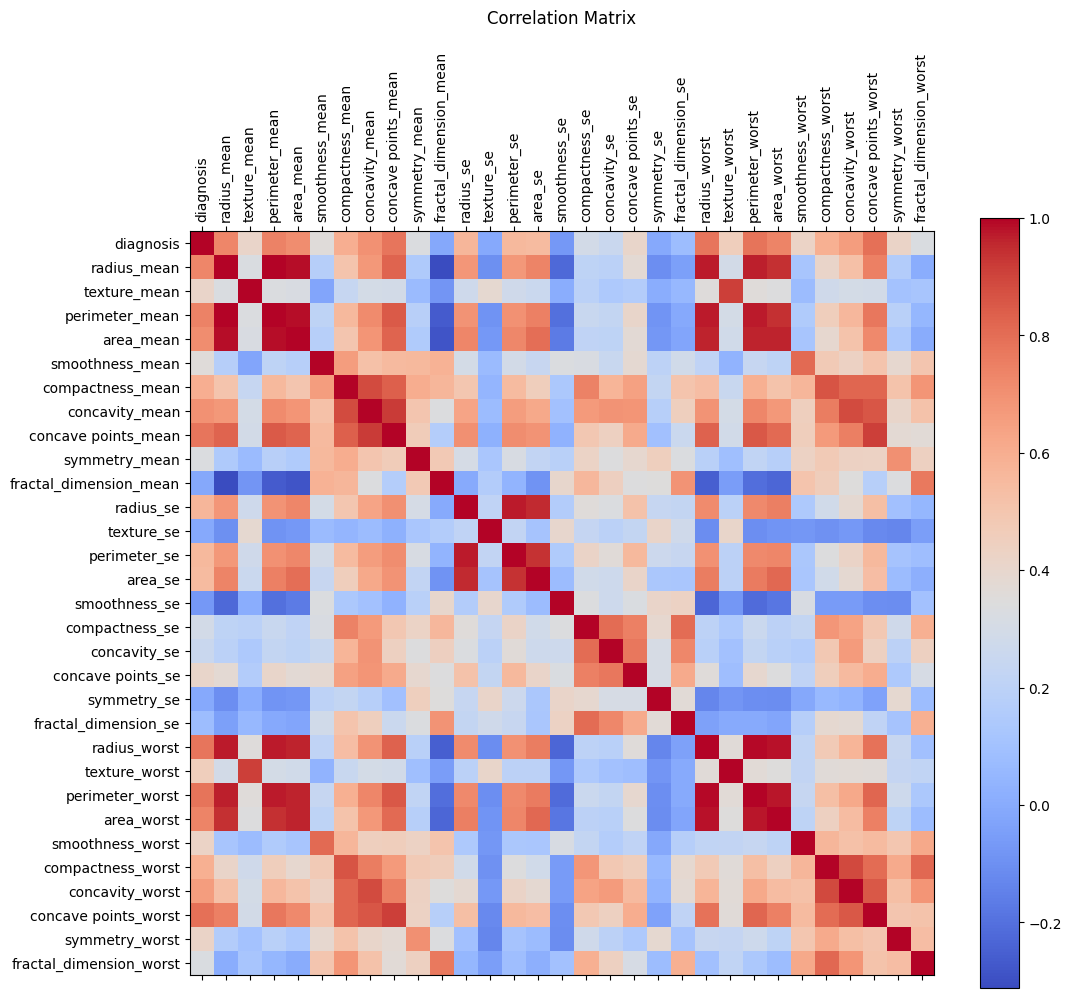

In [11]:
import matplotlib.pyplot as plt

correlation = df.corr()

fig, ax = plt.subplots(figsize=(12,10))

cax = ax.matshow(correlation, cmap="coolwarm")

fig.colorbar(cax)

ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.columns)))

ax.set_xticklabels(correlation.columns, rotation=90)
ax.set_yticklabels(correlation.columns)

plt.title("Correlation Matrix", pad=20)

plt.show()

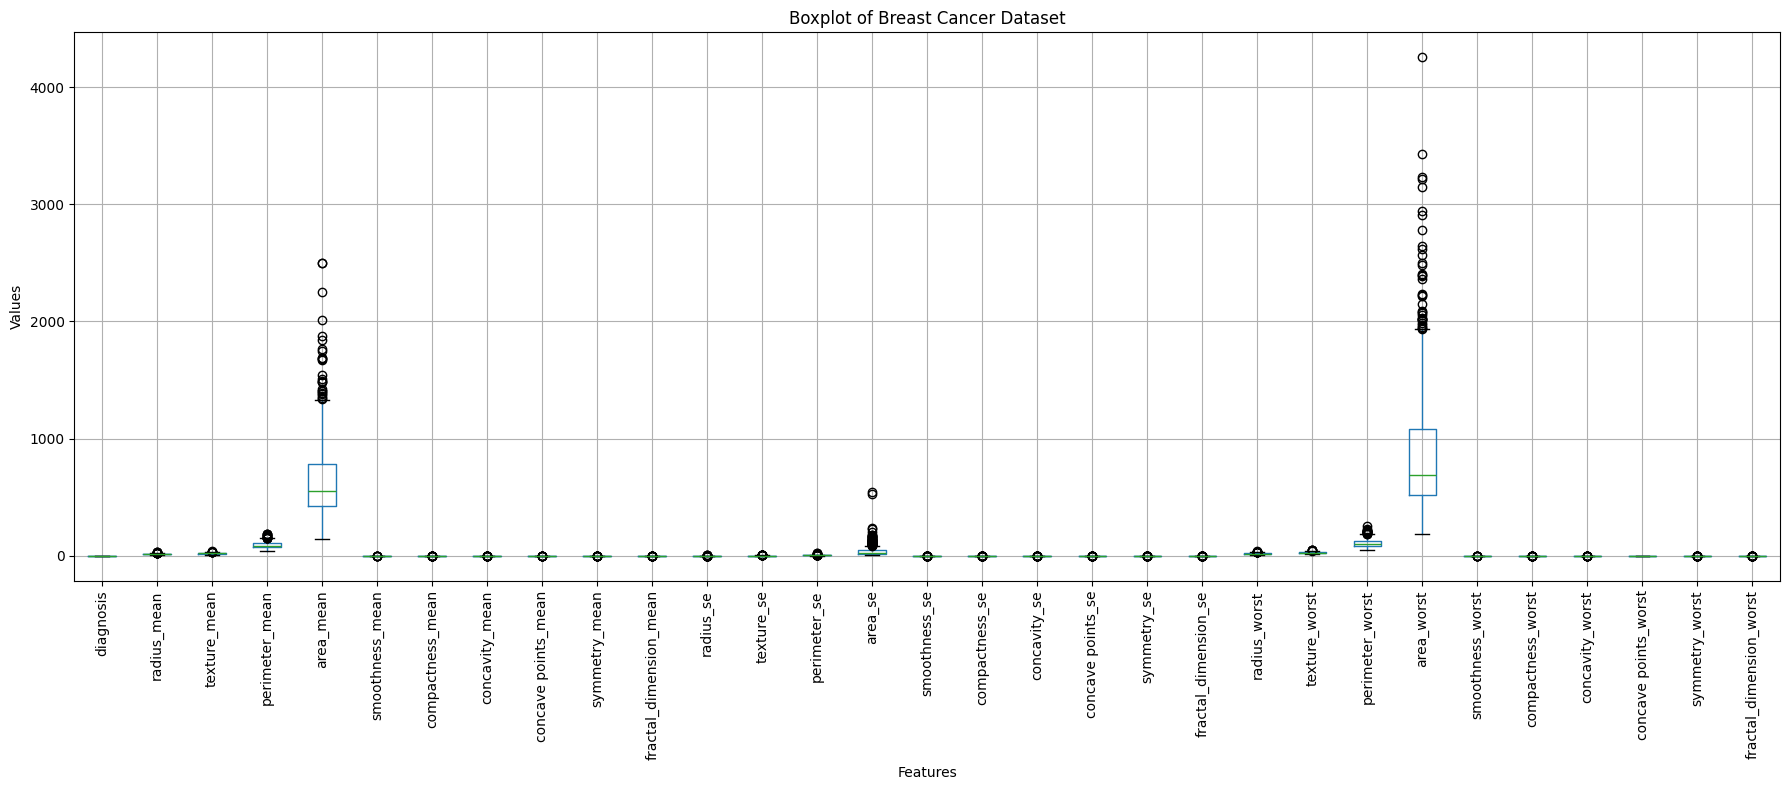

In [12]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(18,8))

ax = fig.add_subplot(111)

df.boxplot(ax=ax)

ax.set_title("Boxplot of Breast Cancer Dataset")
ax.set_xlabel("Features")
ax.set_ylabel("Values")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [13]:
feature_cols = df.columns.drop("diagnosis")

X = df[feature_cols]
Y = df["diagnosis"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.3,
    random_state=42
)

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [16]:
from sklearn.svm import SVC

model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

In [17]:
model.fit(X_train, Y_train)

SVC(random_state=42)

In [18]:
Y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test, Y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9766081871345029


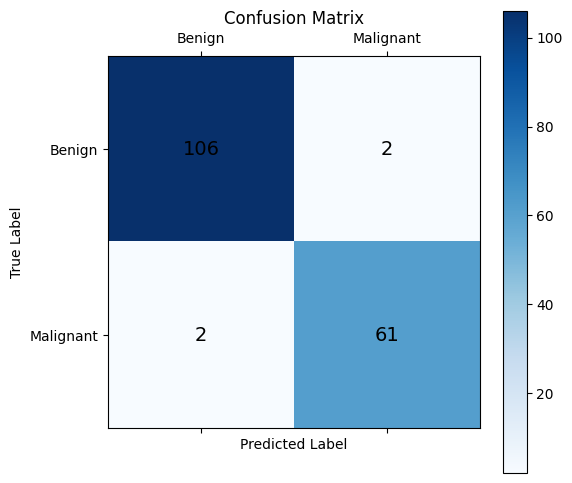

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, Y_pred)

fig, ax = plt.subplots(figsize=(6,6))

cax = ax.matshow(cm, cmap="Blues")

fig.colorbar(cax)

# Display values inside the cells
for i in range(len(cm)):
    for j in range(len(cm[0])):
        ax.text(j, i, cm[i, j],
                ha='center',
                va='center',
                color='black',
                fontsize=14)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix")

ax.set_xticks([0,1])
ax.set_yticks([0,1])

ax.set_xticklabels(["Benign","Malignant"])
ax.set_yticklabels(["Benign","Malignant"])

plt.show()

In [21]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       108
           1       0.97      0.97      0.97        63

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171

